Generation 0: Best Fitness = 0.2825, Best Solution: x=-0.8022, y=0.8069
Generation 10: Best Fitness = 0.9638, Best Solution: x=0.9816, y=0.9729
Generation 20: Best Fitness = 0.9994, Best Solution: x=0.9759, y=1.0220
Generation 30: Best Fitness = 0.9982, Best Solution: x=0.4536, y=0.8941
Generation 40: Best Fitness = 0.9996, Best Solution: x=0.9716, y=0.9800
Generation 50: Best Fitness = 0.9990, Best Solution: x=0.9816, y=0.9525
Generation 60: Best Fitness = 0.9995, Best Solution: x=0.9814, y=0.9425
Generation 70: Best Fitness = 0.9995, Best Solution: x=0.9810, y=0.9505
Generation 80: Best Fitness = 0.9997, Best Solution: x=0.9773, y=0.9738
Generation 90: Best Fitness = 0.9996, Best Solution: x=0.9771, y=0.9903

Final Results:
Optimal solution: x = 0.986609, y = 0.974296
Function value: f(0.986609, 0.974296) = 0.000260
Fitness value: 0.999740


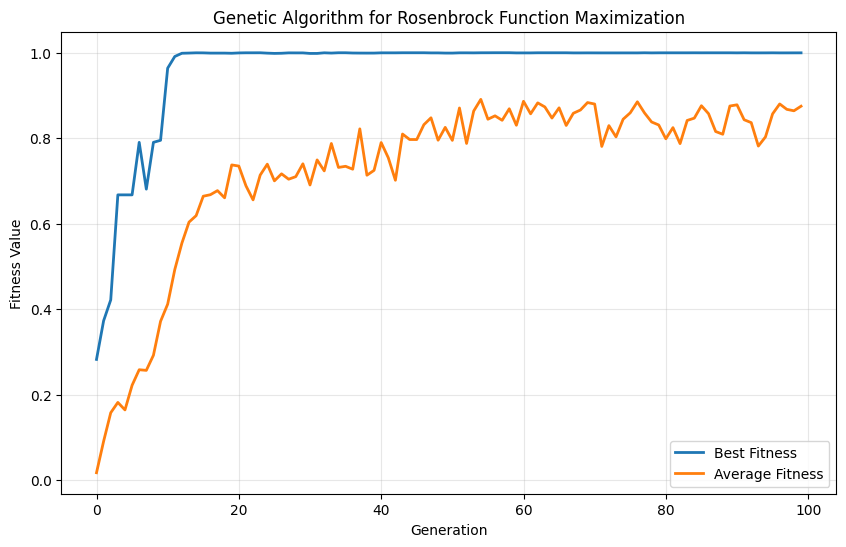

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Rosenbrock函数定义
def rosenbrock(x, y):
    return (1 - x)**2 + 100 * (y - x**2)**2

# 2. 适应度函数（求极大值）
def fitness_function(x, y):
    # 使用倒数形式将最小化问题转化为最大化问题
    return 1 / (1 + rosenbrock(x, y))

# 3. 二进制编码解码函数
def decode_chromosome(chromosome):
    # 前16位表示x，后16位表示y
    x_bits = chromosome[:16]
    y_bits = chromosome[16:]

    # 将二进制转换为十进制
    x_int = int(x_bits, 2)
    y_int = int(y_bits, 2)

    # 映射到[-2.048, 2.048]区间
    x = -2.048 + (x_int / 65535) * 4.096
    y = -2.048 + (y_int / 65535) * 4.096

    return x, y

# 4. 初始化种群
def initialize_population(pop_size, chrom_length):
    population = []
    for _ in range(pop_size):
        # 随机生成二进制字符串
        chromosome = ''.join(str(np.random.randint(0, 2)) for _ in range(chrom_length))
        population.append(chromosome)
    return population

# 5. 选择操作（轮盘赌选择）
def selection(population, fitness_values):
    total_fitness = sum(fitness_values)
    probabilities = [f/total_fitness for f in fitness_values]

    # 使用轮盘赌选择
    selected_indices = np.random.choice(
        range(len(population)),
        size=len(population),
        p=probabilities,
        replace=True
    )

    return [population[i] for i in selected_indices]

# 6. 交叉操作
def crossover(parent1, parent2, crossover_rate):
    if np.random.rand() < crossover_rate:
        # 随机选择交叉点
        crossover_point = np.random.randint(1, len(parent1)-1)
        child1 = parent1[:crossover_point] + parent2[crossover_point:]
        child2 = parent2[:crossover_point] + parent1[crossover_point:]
        return child1, child2
    else:
        return parent1, parent2

# 7. 变异操作
def mutation(chromosome, mutation_rate):
    chromosome = list(chromosome)
    for i in range(len(chromosome)):
        if np.random.rand() < mutation_rate:
            # 翻转该位
            chromosome[i] = '1' if chromosome[i] == '0' else '0'
    return ''.join(chromosome)

# 8. 主函数 - 遗传算法
def genetic_algorithm(pop_size=100, chrom_length=32, generations=100,
                     crossover_rate=0.8, mutation_rate=0.01):

    # 初始化种群
    population = initialize_population(pop_size, chrom_length)
    best_fitness_history = []
    avg_fitness_history = []

    for generation in range(generations):
        # 计算适应度
        fitness_values = []
        for chrom in population:
            x, y = decode_chromosome(chrom)
            fitness_values.append(fitness_function(x, y))

        # 记录最佳适应度
        best_fitness = max(fitness_values)
        avg_fitness = np.mean(fitness_values)
        best_fitness_history.append(best_fitness)
        avg_fitness_history.append(avg_fitness)

        # 选择
        selected_population = selection(population, fitness_values)

        # 交叉
        new_population = []
        for i in range(0, len(selected_population), 2):
            if i+1 < len(selected_population):
                child1, child2 = crossover(
                    selected_population[i],
                    selected_population[i+1],
                    crossover_rate
                )
                new_population.extend([child1, child2])
            else:
                new_population.append(selected_population[i])

        # 变异
        population = [mutation(chrom, mutation_rate) for chrom in new_population]

        # 输出当前代信息
        if generation % 10 == 0:
            best_idx = np.argmax(fitness_values)
            best_chrom = population[best_idx]
            best_x, best_y = decode_chromosome(best_chrom)
            print(f"Generation {generation}: Best Fitness = {best_fitness:.4f}, "
                  f"Best Solution: x={best_x:.4f}, y={best_y:.4f}")

    # 获取最终最优解
    final_fitness_values = []
    for chrom in population:
        x, y = decode_chromosome(chrom)
        final_fitness_values.append(fitness_function(x, y))

    best_idx = np.argmax(final_fitness_values)
    best_chrom = population[best_idx]
    best_x, best_y = decode_chromosome(best_chrom)

    return best_x, best_y, best_fitness_history, avg_fitness_history

# 9. 运行遗传算法并可视化结果
if __name__ == "__main__":
    # 运行遗传算法
    best_x, best_y, best_history, avg_history = genetic_algorithm()

    print(f"\nFinal Results:")
    print(f"Optimal solution: x = {best_x:.6f}, y = {best_y:.6f}")
    print(f"Function value: f({best_x:.6f}, {best_y:.6f}) = {rosenbrock(best_x, best_y):.6f}")
    print(f"Fitness value: {fitness_function(best_x, best_y):.6f}")

    # 绘制适应度曲线
    plt.figure(figsize=(10, 6))
    plt.plot(best_history, label='Best Fitness', linewidth=2)
    plt.plot(avg_history, label='Average Fitness', linewidth=2)
    plt.xlabel('Generation')
    plt.ylabel('Fitness Value')
    plt.title('Genetic Algorithm for Rosenbrock Function Maximization')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('convergence_curve.png')
    plt.show()